Hotel operators in Crimson Pagoda Hotel want to improve their business efficiency by utilizing their historical data and they want to find out what happened in their previous bookings, knowing their customer better, and optimizing the promo timing. Data will be analyzed based on questions that have been predetermined by the CEO of the hotel.

1. Where do the majority of the guests come from?
2. What is the average daily rate (ADR) paid by guests for their stays?
3. How does the average daily rate vary by month?
4. Which are the busiest months based on guest arrivals?
5. How long do guests typically stay in the hotels?
6. What is the distribution of bookings by market segment?
7. How many bookings were canceled?
8. Which month has the highest number of cancellations?
9. How many bookings involved previous cancellations?
10. Which customer type (e.g., transient, contract) books the most?
11. What is the average waiting list time for bookings?
12. Which room types are most frequently reserved versus assigned?



In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Crimson_Pagoda_Hotel.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
def missingvalue(data):
    missing_value = data.isnull().sum(axis = 0).reset_index()
    missing_value.columns = ['variable', 'number_of_missing']
    missing_value['percentage_of_missing'] = (missing_value['number_of_missing'])/data.shape[0]*100
    mv = missing_value.sort_values('percentage_of_missing', ascending = False).reset_index(drop=True)
    return mv
missingvalue(df)

,variable,number_of_missing,percentage_of_missing
0,company,112593,94.306893
1,agent,16340,13.686238
2,country,488,0.408744
3,children,4,0.003350
4,reserved_room_type,0,0.000000
5,assigned_room_type,0,0.000000
6,booking_changes,0,0.000000
7,deposit_type,0,0.000000
8,hotel,0,0.000000
9,previous_cancellations,0,0.000000


# Handling missing value


The company column will be dropped because the number of missing values is more than 80%. The column agent and children have missing values less than 20% and are discrete variables, so they will be filled with mode. The country column has 0.4% missing values and is a categorical variable. This column will be filled with mode, because it will not change the meaning of the data.

In [ ]:
#Drop column because missing value greater than 80%
if 'company' in df.columns:
    df.drop('company', axis=1, inplace=True)

#Fill agents, country_origin, and children with mode
if 'agent' in df.columns:
    df['agent'].fillna(df['agent'].mode()[0], inplace=True)

if 'country' in df.columns:
    df['country'].fillna(df['country'].mode()[0], inplace=True)

if 'children' in df.columns:
    df['children'].fillna(df['children'].mode()[0], inplace=True)

missingvalue(df)

,variable,number_of_missing,percentage_of_missing
0,hotel,0,0.0
1,is_repeated_guest,0,0.0
2,reservation_status,0,0.0
3,total_of_special_requests,0,0.0
4,required_car_parking_spaces,0,0.0
5,adr,0,0.0
6,customer_type,0,0.0
7,days_in_waiting_list,0,0.0
8,agent,0,0.0
9,deposit_type,0,0.0


# 1. Where do the majority of the guests come from?

In [ ]:
df_nocancel = df[df['is_canceled']==False]
df_nocancelrepeat = df[(df['is_canceled']==False) & (df['is_repeated_guest']==0)]

In [ ]:
print(df_nocancelrepeat['country'].value_counts())

country
PRT    18764
GBR     9570
FRA     8409
ESP     6307
DEU     6044
       ...  
BHR        1
DJI        1
MLI        1
NPL        1
FRO        1
Name: count, Length: 165, dtype: int64


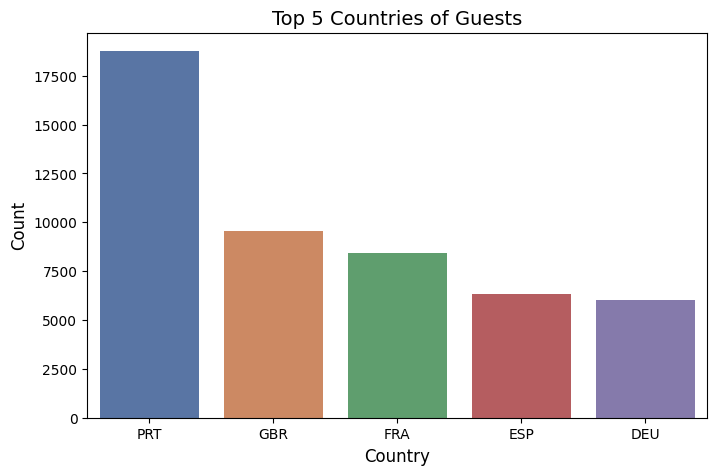

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_nocancelrepeat,
    x="country",
    order=df_nocancelrepeat["country"].value_counts().iloc[:5].index,
    palette="deep",
)
ax.set_title("Top 5 Countries of Guests", size=14)
ax.set_xlabel("Country", size=12)
ax.set_ylabel("Count", size=12)
plt.show()

The bar chart shows that Portugal (PRT) has the highest number of guests, followed by the United Kingdom (GBR), France (FRA), Spain (ESP), and Germany (DEU) in descending order.

# 2. What is the average daily rate (ADR) paid by guests for their stays?

In [ ]:
all_hotel = df[(df['is_canceled']== False) & (df['adr']>0)]
rh = df[(df['is_canceled']== False) & (df['adr']>0) & (df['hotel']=='Resort Hotel')]
ch = df[(df['is_canceled']== False) & (df['adr']>0) & (df['hotel']=='City Hotel')]

In [ ]:
price_type = all_hotel.groupby('hotel')['adr'].mean()

print('The average price for all hotel is ${}'.format(all_hotel['adr'].mean()))
print('The average price for Resort Hotel is ${}'.format(rh['adr'].mean()))
print('The average price for City Hotel is ${}'.format(ch['adr'].mean()))

The average price for all hotel is $102.36698007327804
The average price for Resort Hotel is $92.93447506190307
The average price for City Hotel is $108.27313340273318


In [ ]:
price_room = pd.pivot_table(all_hotel, index = ['hotel', 'assigned_room_type'], values = 'adr', aggfunc = np.mean )
print('The following is the average price for each room type for each hotel type:\n')
price_room

The following is the average price for each room type for each hotel type:



adr
hotel        assigned_room_type            
City Hotel   A                    99.078326
             B                    97.518135
             C                   110.417879
             D                   117.913473
             E                   142.225000
             F                   178.171620
             G                   196.841696
             K                   102.107391
Resort Hotel A                    81.309890
             B                   105.815517
             C                   108.913320
             D                    82.425891
             E                   102.462598
             F                   120.389556
             G                   153.179443
             H                   162.198575
             I                    90.872089

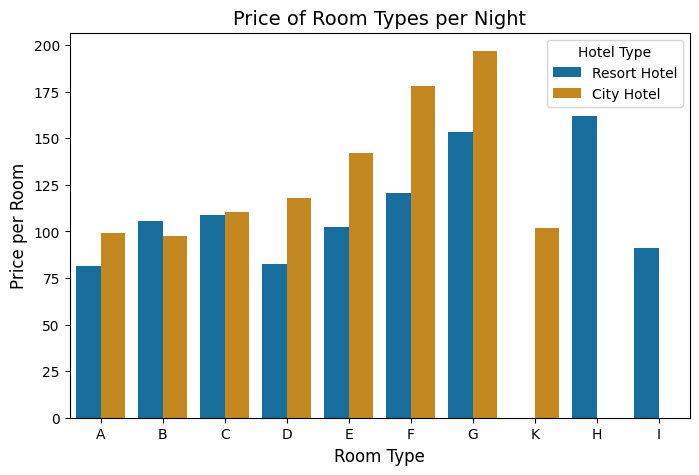

In [ ]:
plt.figure(figsize = (8,5))
ax = sns.barplot(x='assigned_room_type', y='adr', data = price_room.reset_index(), hue= 'hotel',
                 palette = "colorblind", hue_order = ["Resort Hotel", "City Hotel"])
ax.set_title("Price of Room Types per Night", size = 14)
ax.set_xlabel("Room Type", size = 12)
ax.set_ylabel("Price per Room", size = 12)
ax.legend().set_title("Hotel Type")
plt.show()

The bar chart shows that City Hotels generally have higher room prices than Resort Hotels, especially for room types E, F, and G, while Resort Hotels have the highest price for room type H.

# 3. How does the average daily rate vary by month?

In [ ]:
# Ensure 'arrival_date_month' is in the correct order (month names)
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

In [ ]:
# Group by month and calculate the average daily rate (ADR)
avg_adr_by_month = (
    df.groupby('arrival_date_month')['adr']
    .mean()
    .reindex(month_order)  # Ensure the months are in the correct order
)


In [ ]:
# Reset index for easier plotting
avg_adr_by_month = avg_adr_by_month.reset_index()
avg_adr_by_month.columns = ['Month', 'Average ADR']

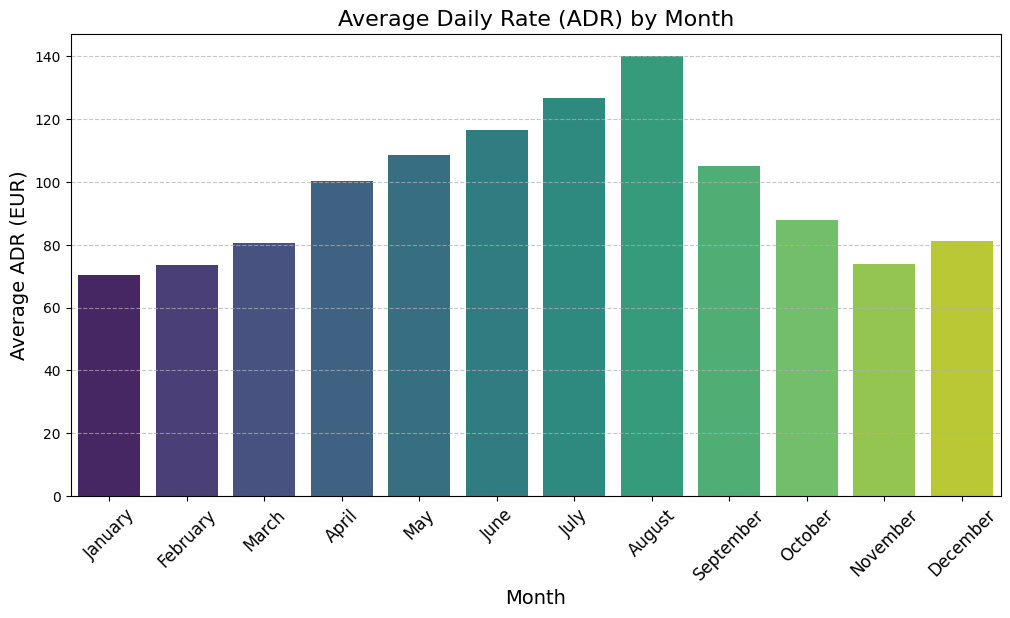

In [ ]:
# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='Average ADR', data=avg_adr_by_month, palette='viridis')
plt.title('Average Daily Rate (ADR) by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average ADR (EUR)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The bar chart shows that the Average Daily Rate (ADR) is highest in August and lowest in January, with prices generally increasing from the beginning of the year, peaking in summer, and then declining towards the end of the year.

# 4. Which are the busiest months based on guest arrivals?

In [ ]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

In [ ]:
bookings_by_month = (
    df['arrival_date_month']
    .value_counts()
    .reindex(month_order)
)

In [ ]:
bookings_by_month = bookings_by_month.reset_index()
bookings_by_month.columns = ['Month', 'Number of Bookings']


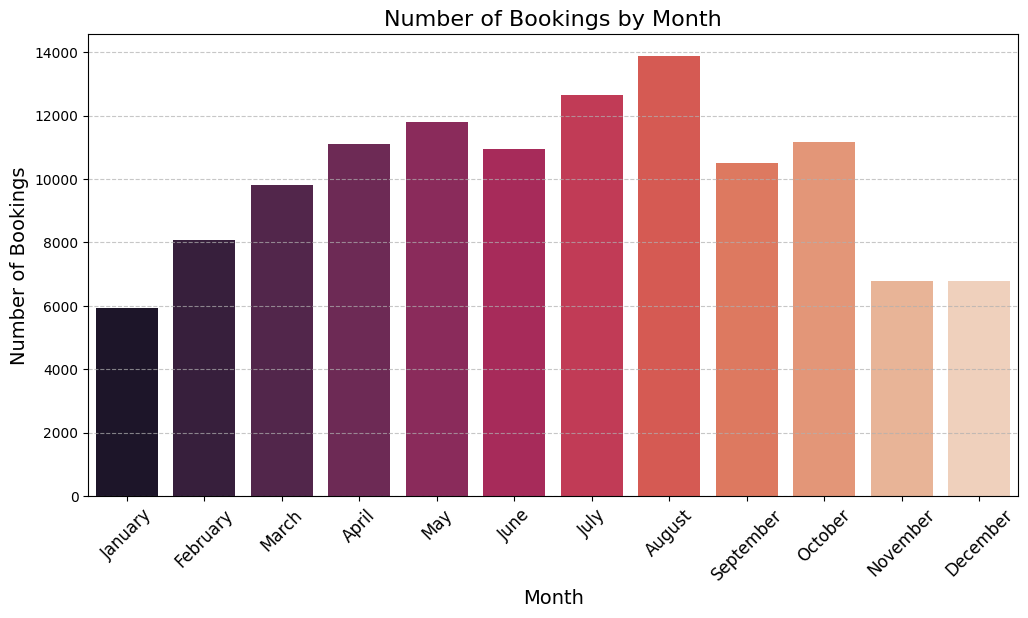

In [ ]:
# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='Number of Bookings', data=bookings_by_month, palette='rocket')
plt.title('Number of Bookings by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The number of bookings increases from January, peaks in August, and then declines towards December.

# 5. How long do guests typically stay in the hotels?

In [ ]:
df['total_stay_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

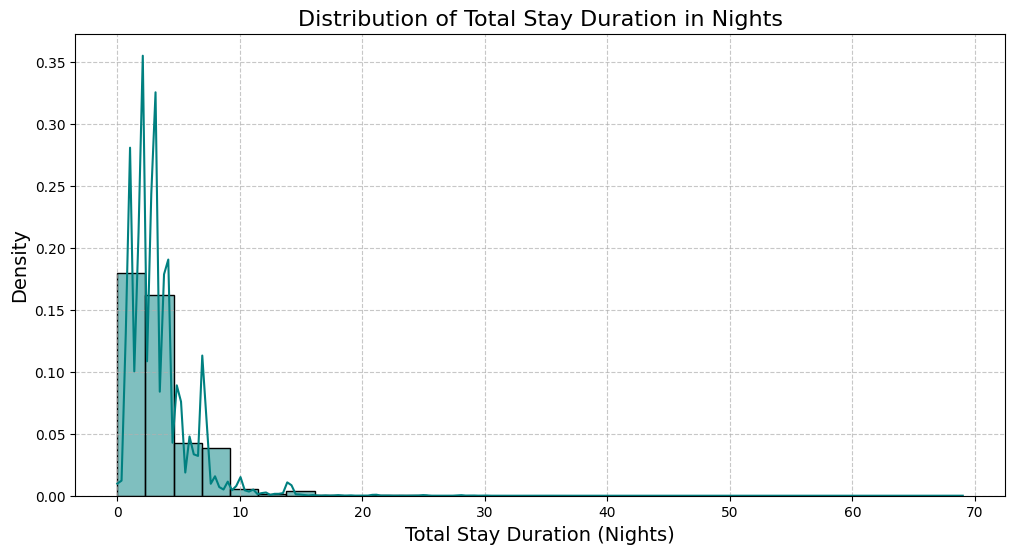

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['total_stay_nights'], bins=30, kde=True, color='teal', stat='density')
plt.title('Distribution of Total Stay Duration in Nights', fontsize=16)
plt.xlabel('Total Stay Duration (Nights)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The distribution of total stay duration is highly skewed to the right, with most stays being short and only a few extending beyond 10 nights.

# 6. What is the distribution of bookings by market segment?


In [ ]:
bookings_by_market_segment = df['market_segment'].value_counts()

In [ ]:
bookings_by_market_segment = bookings_by_market_segment.reset_index()
bookings_by_market_segment.columns = ['Market Segment', 'Number of Bookings']

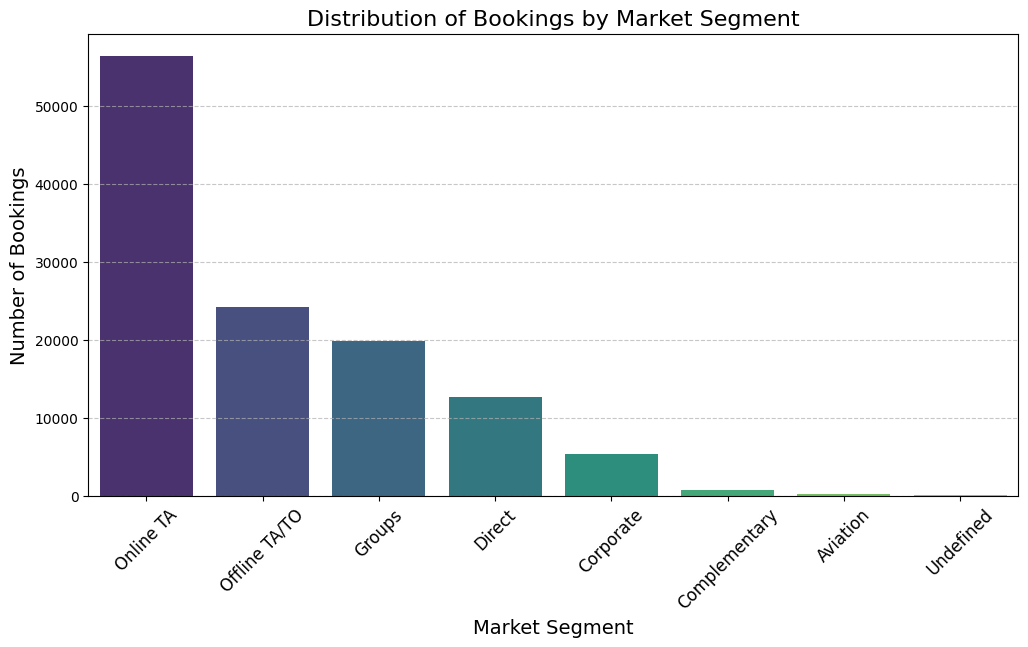

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Market Segment', y='Number of Bookings', data=bookings_by_market_segment, palette='viridis')
plt.title('Distribution of Bookings by Market Segment', fontsize=16)
plt.xlabel('Market Segment', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The majority of bookings come from the "Online TA" market segment, followed by "Offline TA/TO" and "Groups," while other segments contribute significantly fewer bookings.

# 7. How many bookings were canceled?


In [ ]:
# Calculate the total number of cancellations (is_canceled == 1)
total_cancellations = df['is_canceled'].sum()

In [ ]:
# Calculate the total number of bookings (is_canceled == 0)
total_bookings = len(df) - total_cancellations

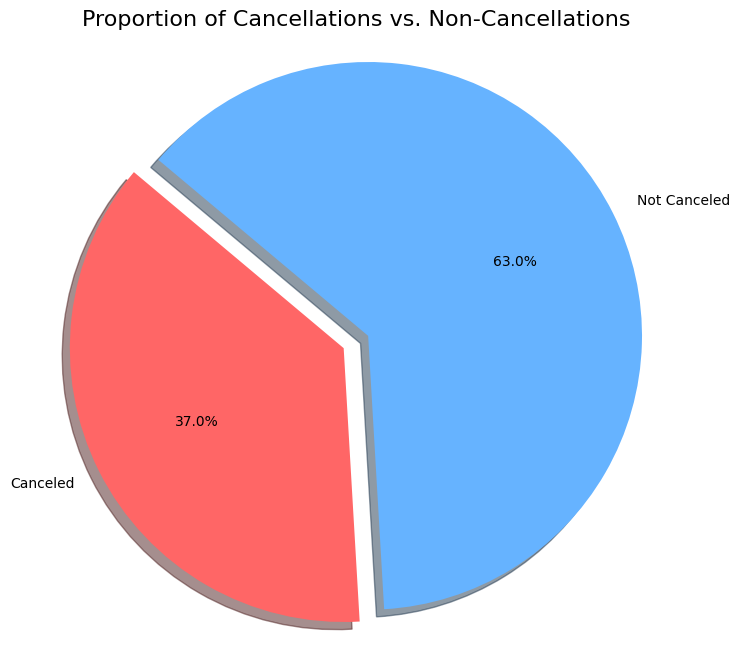

In [ ]:
# Visualization: Pie chart to show the proportion of cancellations
labels = ['Canceled', 'Not Canceled']
sizes = [total_cancellations, total_bookings]
colors = ['#ff6666', '#66b3ff']
explode = (0.1, 0)
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, shadow=True)
plt.title('Proportion of Cancellations vs. Non-Cancellations', fontsize=16)
plt.axis('equal')
plt.show()


# 8. Which month has the highest number of cancellations?


In [ ]:
# Group the data by month and calculate the total number of cancellations for each month
cancellations_by_month = df.groupby('arrival_date_month')['is_canceled'].sum().sort_values(ascending=False)

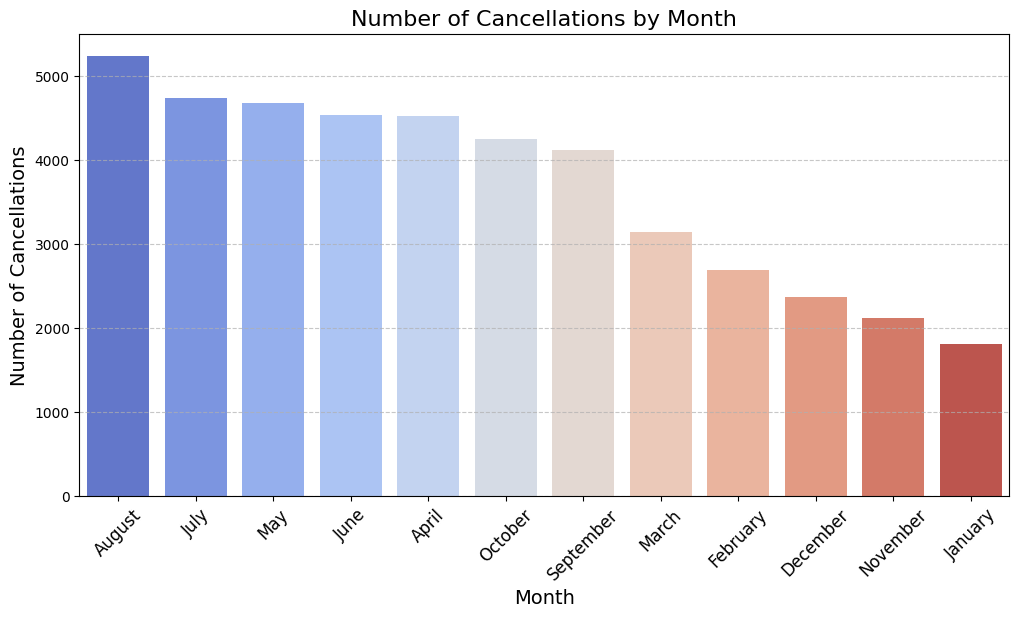

In [ ]:
# Visualization: Bar plot to show cancellations by month
plt.figure(figsize=(12, 6))
sns.barplot(x=cancellations_by_month.index, y=cancellations_by_month.values, palette='coolwarm')
plt.title('Number of Cancellations by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Cancellations', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
month_with_highest_cancellations = cancellations_by_month.idxmax()
highest_cancellations = cancellations_by_month.max()

print(f'The month with the highest number of cancellations is {month_with_highest_cancellations} with {highest_cancellations} cancellations.')

The month with the highest number of cancellations is August with 5239 cancellations.


# 9. How many bookings involved previous cancellations?

In [ ]:
# Calculate the number of bookings that involved previous cancellations
previous_cancellations_count = df['previous_cancellations'].sum()

# Calculate the total number of bookings
total_bookings = len(df)

In [ ]:
# Calculate the percentage of bookings with previous cancellations
percentage_previous_cancellations = (previous_cancellations_count / total_bookings) * 100

# Print the result
print(f'Total number of bookings with previous cancellations: {previous_cancellations_count}')
print(f'This represents {percentage_previous_cancellations:.2f}% of the total bookings.')

Total number of bookings with previous cancellations: 10401
This represents 8.71% of the total bookings.


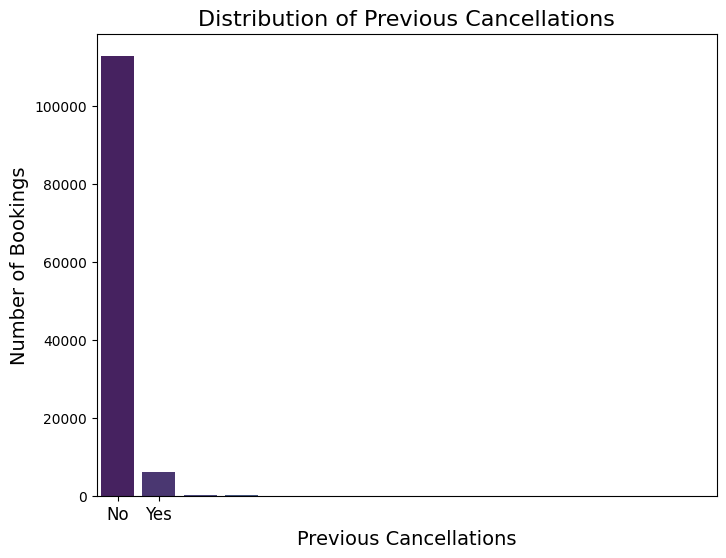

In [ ]:
# Visualization: Distribution of previous cancellations
plt.figure(figsize=(8, 6))
sns.countplot(x='previous_cancellations', data=df, palette='viridis')
plt.title('Distribution of Previous Cancellations', fontsize=16)
plt.xlabel('Previous Cancellations', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.xticks([0, 1], ['No', 'Yes'], fontsize=12)
plt.show()

# 10. Which customer type (e.g., transient, contract) books the most?


In [ ]:
# Count the number of bookings for each customer type
customer_type_counts = df['customer_type'].value_counts()

# Print the counts for each customer type
print(customer_type_counts)

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


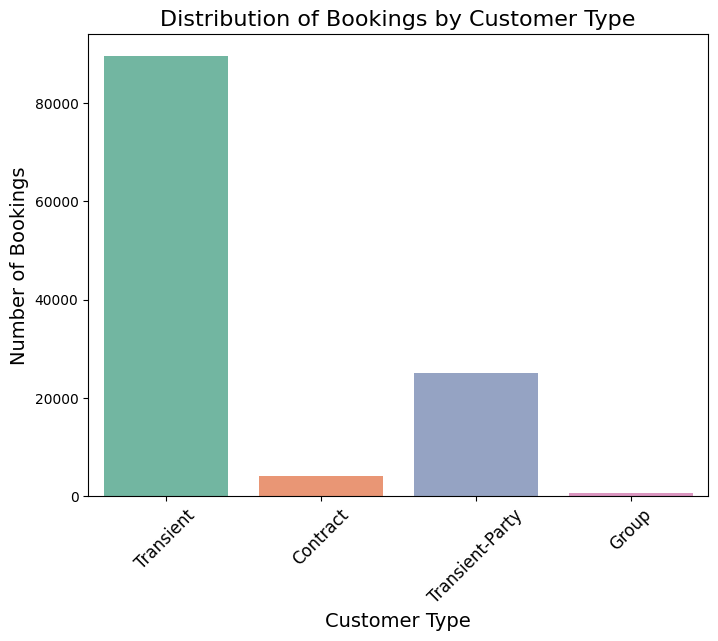

In [ ]:
# Visualization: Distribution of bookings by customer type
plt.figure(figsize=(8, 6))
sns.countplot(x='customer_type', data=df, palette='Set2')
plt.title('Distribution of Bookings by Customer Type', fontsize=16)
plt.xlabel('Customer Type', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.show()

# 11. What is the average waiting list time for bookings?

In [ ]:
# Calculate the average waiting list time
average_waiting_time = df['days_in_waiting_list'].mean()

# Print the result
print(f'The average waiting list time for bookings is {average_waiting_time:.2f} days.')


The average waiting list time for bookings is 2.32 days.


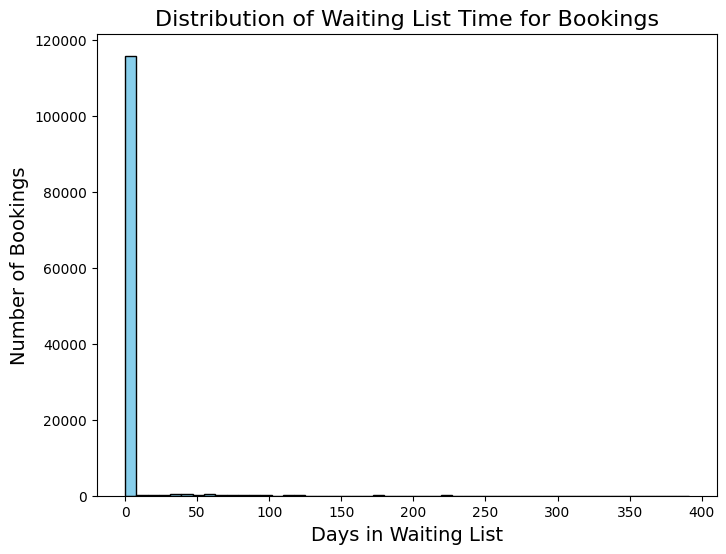

In [ ]:
# Visualization: Distribution of waiting list time
plt.figure(figsize=(8, 6))
plt.hist(df['days_in_waiting_list'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Waiting List Time for Bookings', fontsize=16)
plt.xlabel('Days in Waiting List', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.show()

# 12. Which room types are most frequently reserved versus assigned?

In [ ]:
# Calculate the number of mismatches in room types
room_type_mismatch = df[df['reserved_room_type'] != df['assigned_room_type']]

# Count the frequency of each room type reserved and assigned
reserved_room_counts = df['reserved_room_type'].value_counts()
assigned_room_counts = df['assigned_room_type'].value_counts()

# Print the results
print('Reserved Room Type Counts:\n', reserved_room_counts)
print('\nAssigned Room Type Counts:\n', assigned_room_counts)
print(f'\nNumber of mismatched room assignments: {len(room_type_mismatch)}')

Reserved Room Type Counts:
 reserved_room_type
A    85994
D    19201
E     6535
F     2897
G     2094
B     1118
C      932
H      601
P       12
L        6
Name: count, dtype: int64

Assigned Room Type Counts:
 assigned_room_type
A    74053
D    25322
E     7806
F     3751
G     2553
C     2375
B     2163
H      712
I      363
K      279
P       12
L        1
Name: count, dtype: int64

Number of mismatched room assignments: 14917


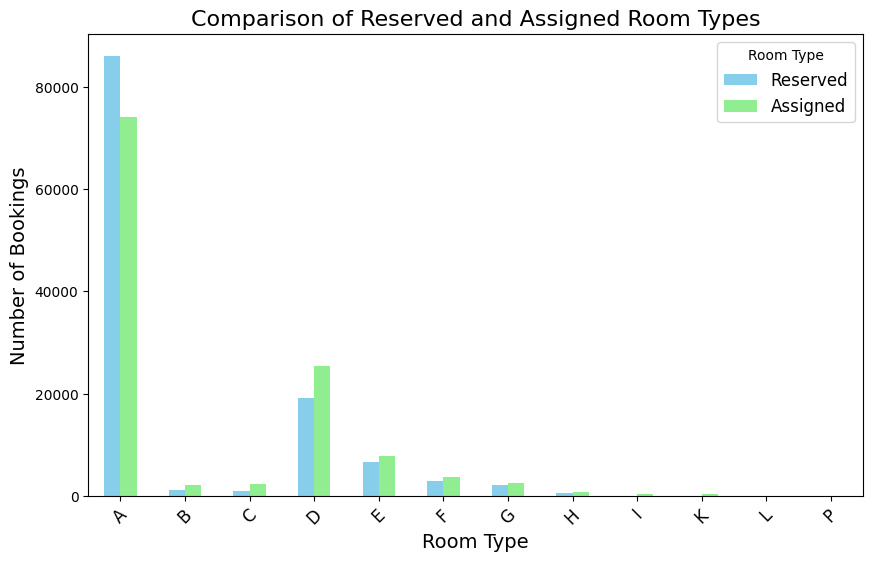

In [ ]:
# Visualization: Comparison of reserved vs assigned room types
room_type_comparison = pd.DataFrame({
    'Reserved': reserved_room_counts,
    'Assigned': assigned_room_counts
}).fillna(0)

room_type_comparison.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightgreen'])
plt.title('Comparison of Reserved and Assigned Room Types', fontsize=16)
plt.xlabel('Room Type', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.legend(title='Room Type', fontsize=12)
plt.show()